# 05 SVM + 神经网络：四个方案对照

报告第四节的核心。四个方案在**完全相同**的数据切分上比较：

| 方案 | 做法 |
|---|---|
| 单独 SVM | 和 02 一样的 RBF 核 SVM |
| 单独 MLP | 和 04 一样的两层神经网络 |
| 串行（MLP → SVM） | 先训练 MLP，把它最后一层隐藏层（32 维）的输出当作新特征，再训练一个 SVM。分工：MLP 负责"把数据变换到好分的空间"，SVM 负责"在新空间里画最宽的分界线" |
| 并行（概率平均） | SVM 和 MLP 各自判断同一笔交易，把两个"欺诈概率"取平均。两个模型犯错的地方不一样，平均后可以互相抵消一部分 |

另外加两个扩展方案，用来排除一个干扰因素（见第 3、4 节）：
- 串行 B（MLP → 线性 SVM，全量）：串行里的 SVM 换成线性 SVM，用全部训练数据。
- 并行 B（验证集选权重）：不再固定一人一半，而是在验证集上挑 MLP 和 SVM 各占多少权重。

前提：先跑过 02、04，数据目录里要有 `train_scaled.csv`、`test_scaled.csv`、`train_amount_raw.csv`、`test_amount_raw.csv`。

## 0. 准备

In [1]:
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

if os.path.exists('/content'):
    os.system('apt-get -qq install -y fonts-noto-cjk > /dev/null')
    font_path = glob.glob('/usr/share/fonts/**/NotoSansCJK*-Regular.ttc', recursive=True)[0]
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
else:
    plt.rcParams['font.family'] = ['PingFang SC', 'Heiti SC', 'Arial Unicode MS', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
import time
import warnings
import numpy as np
import pandas as pd
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = '/content/drive/MyDrive/data-mining'
except ImportError:
    DATA_DIR = os.environ.get('CCFD_DATA_DIR', 'data')

train_df = pd.read_csv(f'{DATA_DIR}/train_scaled.csv')
test_df = pd.read_csv(f'{DATA_DIR}/test_scaled.csv')
train_amount = pd.read_csv(f'{DATA_DIR}/train_amount_raw.csv')['Amount'].values
test_amount = pd.read_csv(f'{DATA_DIR}/test_amount_raw.csv')['Amount'].values
feature_cols = [c for c in train_df.columns if c != 'Class']
X_test, y_test = test_df[feature_cols].values, test_df['Class'].values
print(f'训练集 {len(train_df)} 行，测试集 {len(test_df)} 行，测试集欺诈 {y_test.sum()} 笔')

训练集 199391 行，测试集 85416 行，测试集欺诈 145 笔


## 1. 从训练集里再切出一块"验证集"

为什么要切：
- 并行方案要把 SVM 的分数和 MLP 的概率放到同一个尺度上才能平均，这个换算规则要用数据来学；
- 每个方案的阈值也要挑。

这两件事如果直接在测试集上做，就是偷看考卷。所以从训练集里按同样的规矩（分层、相同的行落在同一边）再切 20% 出来当验证集，专门干这两件事。四个方案都只用剩下的 80% 训练，测试集只在最后打分时用一次。

In [3]:
from sklearn.model_selection import train_test_split

row_id = pd.util.hash_pandas_object(train_df, index=False).values
uniq = pd.DataFrame({'row_id': row_id, 'Class': train_df['Class'].values}).drop_duplicates('row_id')
fit_ids, _ = train_test_split(uniq['row_id'], test_size=0.2, stratify=uniq['Class'], random_state=42)
is_fit = np.isin(row_id, fit_ids.values)

fit_df, val_df = train_df[is_fit], train_df[~is_fit]
X_fit, y_fit = fit_df[feature_cols].values, fit_df['Class'].values
X_val, y_val = val_df[feature_cols].values, val_df['Class'].values
val_amount = train_amount[~is_fit]
print(f'拟合用 {len(fit_df)} 行（欺诈 {y_fit.sum()}），验证集 {len(val_df)} 行（欺诈 {y_val.sum()}）')

拟合用 159509 行（欺诈 278），验证集 39882 行（欺诈 69）


## 2. 训练两个基础模型

- SVM：和 02 一样，训练时保留全部欺诈，正常样本随机抽 2 万条。
- MLP：结构和 04 一样（30 → 64 → 32 → 1）。04 的两种不平衡处理（A 不处理、B 欺诈复制 20 份）都训练一遍，用**验证集**上的 AUPRC 选一个，不看测试集。

In [4]:
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import average_precision_score

N_NORMAL = 20000

rng = np.random.default_rng(42)
normal_idx = np.flatnonzero(y_fit == 0)
svm_rows = np.concatenate([np.flatnonzero(y_fit == 1),
                           rng.choice(normal_idx, N_NORMAL, replace=False)])

start = time.time()
svm = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm.fit(X_fit[svm_rows], y_fit[svm_rows])
train_time = {'单独 SVM': time.time() - start}

def mlp_rows_for(variant):
    if variant == 'B':
        fraud_rows = np.flatnonzero(y_fit == 1)
        return rng.permutation(np.concatenate([normal_idx] + [fraud_rows] * 20))
    return np.arange(len(y_fit))

candidates = {}
for variant in ['A', 'B']:
    rows = mlp_rows_for(variant)
    start = time.time()
    m = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', max_iter=20, random_state=42)
    m.fit(X_fit[rows], y_fit[rows])
    candidates[variant] = (m, time.time() - start,
                           average_precision_score(y_val, m.predict_proba(X_val)[:, 1]))
    print(f'MLP 方案 {variant}：验证集 AUPRC = {candidates[variant][2]:.4f}')

MLP_VARIANT = max(candidates, key=lambda v: candidates[v][2])
mlp, train_time['单独 MLP'], _ = candidates[MLP_VARIANT]
print('按验证集选用 MLP 方案', MLP_VARIANT)
print({k: round(v, 1) for k, v in train_time.items()}, '秒')

MLP 方案 A：验证集 AUPRC = 0.8715


MLP 方案 B：验证集 AUPRC = 0.8556
按验证集选用 MLP 方案 A
{'单独 SVM': 0.9, '单独 MLP': 4.6} 秒


## 3. 串行：MLP 的隐藏层 → SVM

取出 MLP 最后一层隐藏层的 32 个输出（就是"隐空间"里的坐标），用同样那批样本训练一个新的 SVM。

In [5]:
def hidden(model, X):
    h = np.asarray(X, dtype=float)
    for W, b in zip(model.coefs_[:-1], model.intercepts_[:-1]):
        h = np.maximum(h @ W + b, 0)
    return h

start = time.time()
svm_serial = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm_serial.fit(hidden(mlp, X_fit[svm_rows]), y_fit[svm_rows])
train_time['串行（MLP → SVM）'] = train_time['单独 MLP'] + time.time() - start
print(f"串行总训练耗时 {train_time['串行（MLP → SVM）']:.1f} 秒（含 MLP）")

串行总训练耗时 4.7 秒（含 MLP）


### 3B. 扩展：串行 B（MLP → 线性 SVM，全量）

上面的串行有个不公平的地方：RBF 核 SVM 太慢，只能用 2 万条正常样本训练，而单独 MLP 用的是全部约 16 万条。如果串行输给单独 MLP，可能只是因为它看到的数据少，不是组合方式不好。
线性 SVM 很快，可以用全部数据训练。这也是 Tang 2013（《Deep Learning using Linear Support Vector Machines》）里的做法：神经网络后面接一个线性 SVM。

In [6]:
from sklearn.svm import LinearSVC

start = time.time()
svm_serial_b = LinearSVC(class_weight='balanced', random_state=42)
svm_serial_b.fit(hidden(mlp, X_fit), y_fit)
train_time['串行 B（MLP → 线性 SVM，全量）'] = train_time['单独 MLP'] + time.time() - start
print(f"串行 B 总训练耗时 {train_time['串行 B（MLP → 线性 SVM，全量）']:.1f} 秒（含 MLP）")

串行 B 总训练耗时 6.5 秒（含 MLP）


## 4. 把分数统一换算成"欺诈概率"（校准）

SVM 给的是到分界线的距离，可以是负数；MLP 给的是概率。两者尺度不同，不能直接相加。
做法（叫 Platt 校准）：在验证集上，用每个模型的原始分数去拟合一个简单的逻辑回归，学出"分数 → 概率"的换算规则。这个换算是单调的，不改变排序，所以不影响 AUPRC，只是让四个方案的输出都变成可比的概率。

In [7]:
from sklearn.linear_model import LogisticRegression

def logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

raw_score = {
    '单独 SVM': lambda X: svm.decision_function(X),
    '单独 MLP': lambda X: logit(mlp.predict_proba(X)[:, 1]),
    '串行（MLP → SVM）': lambda X: svm_serial.decision_function(hidden(mlp, X)),
    '串行 B（MLP → 线性 SVM，全量）': lambda X: svm_serial_b.decision_function(hidden(mlp, X)),
}
calib = {name: LogisticRegression().fit(f(X_val).reshape(-1, 1), y_val) for name, f in raw_score.items()}

def prob(name, X):
    return calib[name].predict_proba(raw_score[name](X).reshape(-1, 1))[:, 1]

from sklearn.metrics import average_precision_score

val_prob = {name: prob(name, X_val) for name in raw_score}
val_prob['并行（概率平均）'] = (val_prob['单独 SVM'] + val_prob['单独 MLP']) / 2

weights = np.round(np.arange(0, 1.0001, 0.05), 2)
val_ap = [average_precision_score(y_val, w * val_prob['单独 MLP'] + (1 - w) * val_prob['单独 SVM'])
          for w in weights]
W_MLP = weights[int(np.argmax(val_ap))]
val_prob['并行 B（验证集选权重）'] = W_MLP * val_prob['单独 MLP'] + (1 - W_MLP) * val_prob['单独 SVM']
print(f'并行 B：验证集上最好的权重是 MLP {W_MLP:.2f}，SVM {1 - W_MLP:.2f}')

train_time['并行（概率平均）'] = train_time['单独 SVM'] + train_time['单独 MLP']
train_time['并行 B（验证集选权重）'] = train_time['并行（概率平均）']

并行 B：验证集上最好的权重是 MLP 1.00，SVM 0.00


## 5. 在验证集上挑阈值，在测试集上打分

每个方案在验证集上找让 F1 最高的阈值，然后拿这个阈值去测试集上算成绩。推理耗时 = 把整个测试集（8.5 万笔）预测一遍要多少秒。

In [8]:
from sklearn.metrics import (average_precision_score, f1_score, precision_recall_curve,
                             precision_score, recall_score)

def best_f1_threshold(y, p):
    prec, rec, thr = precision_recall_curve(y, p)
    f1 = 2 * prec[:-1] * rec[:-1] / np.clip(prec[:-1] + rec[:-1], 1e-12, None)
    return thr[np.argmax(f1)]

test_prob, infer_time = {}, {}
single = {name: (lambda X, n=name: prob(n, X)) for name in raw_score}
single['并行（概率平均）'] = lambda X: (prob('单独 SVM', X) + prob('单独 MLP', X)) / 2
single['并行 B（验证集选权重）'] = lambda X: W_MLP * prob('单独 MLP', X) + (1 - W_MLP) * prob('单独 SVM', X)
for name, f in single.items():
    start = time.perf_counter()
    test_prob[name] = f(X_test)
    infer_time[name] = time.perf_counter() - start

descr = {
    '单独 SVM': 'RBF 核，全部欺诈 + 2 万正常样本',
    '单独 MLP': f'30→64→32→1，不平衡处理方案 {MLP_VARIANT}',
    '串行（MLP → SVM）': 'MLP 隐藏层 32 维输出作为 SVM 的输入',
    '并行（概率平均）': 'SVM 与 MLP 校准后的概率取平均',
    '串行 B（MLP → 线性 SVM，全量）': '扩展：隐藏层 → 线性 SVM，用全部训练数据',
    '并行 B（验证集选权重）': f'扩展：验证集选权重，MLP {W_MLP:.2f} / SVM {1 - W_MLP:.2f}',
}
rows, thresholds = [], {}
for name in single:
    t = best_f1_threshold(y_val, val_prob[name])
    thresholds[name] = t
    pred = test_prob[name] >= t
    rows.append({
        '方案': name,
        '方案说明': descr[name],
        'AUPRC': average_precision_score(y_test, test_prob[name]),
        'Recall': recall_score(y_test, pred),
        'Precision': precision_score(y_test, pred, zero_division=0),
        'F1': f1_score(y_test, pred),
        '抓到': int((pred & (y_test == 1)).sum()),
        '误报': int((pred & (y_test == 0)).sum()),
        '阈值(验证集选)': t,
        '训练耗时(秒)': train_time[name],
        '推理耗时(秒)': infer_time[name],
    })
fusion_table = pd.DataFrame(rows).set_index('方案').round(4)
fusion_table.to_csv(f'{DATA_DIR}/results_fusion.csv')
fusion_table

,方案说明,AUPRC,Recall,Precision,F1,抓到,误报,阈值(验证集选),训练耗时(秒),推理耗时(秒)
方案,,,,,,,,,,
单独 SVM,RBF 核，全部欺诈 + 2 万正常样本,0.3270,0.4552,0.4521,0.4536,66,80,0.2679,0.9054,5.9309
单独 MLP,30→64→32→1，不平衡处理方案 A,0.7999,0.7310,0.9298,0.8185,106,8,0.2705,4.5696,0.0281
串行（MLP → SVM）,MLP 隐藏层 32 维输出作为 SVM 的输入,0.7096,0.6828,0.7333,0.7071,99,36,0.2717,4.7384,0.9476
串行 B（MLP → 线性 SVM，全量）,扩展：隐藏层 → 线性 SVM，用全部训练数据,0.7709,0.6552,0.8716,0.7480,95,14,0.3303,6.5202,0.0189
并行（概率平均）,SVM 与 MLP 校准后的概率取平均,0.7416,0.6621,0.8571,0.7471,96,16,0.3669,5.4750,5.7526
并行 B（验证集选权重）,扩展：验证集选权重，MLP 1.00 / SVM 0.00,0.7999,0.7310,0.9298,0.8185,106,8,0.2705,5.4750,5.7217


## 6. 各方案的 PR 曲线

**横轴**：Recall（欺诈抓到的比例）。**纵轴**：Precision（喊欺诈的里面真是欺诈的比例）。**圆点**：验证集挑出的阈值在测试集上的位置。越靠右上角越好。

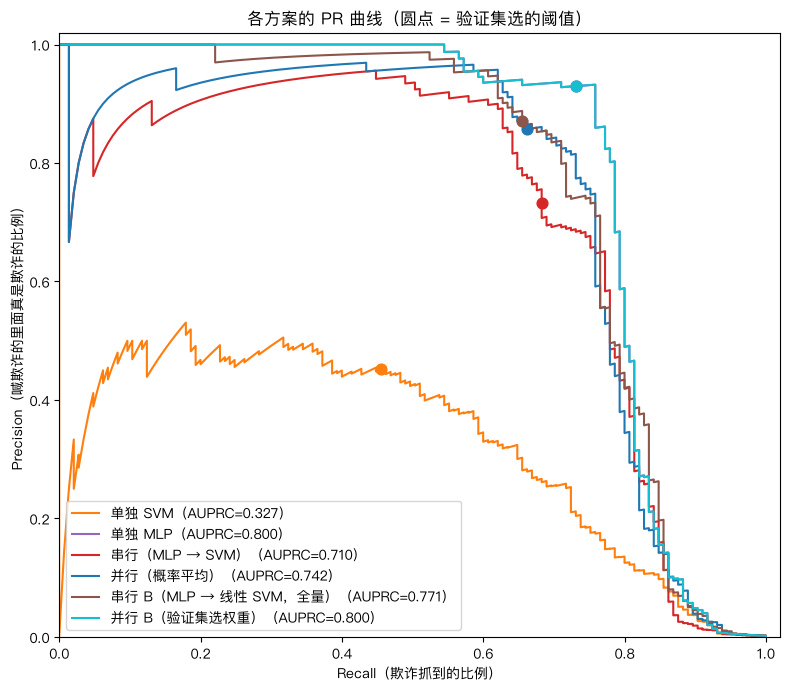

In [9]:
fig, ax = plt.subplots(figsize=(8, 7))
colors = {'单独 SVM': 'tab:orange', '单独 MLP': 'tab:purple',
          '串行（MLP → SVM）': 'tab:red', '并行（概率平均）': 'tab:blue',
          '串行 B（MLP → 线性 SVM，全量）': 'tab:brown', '并行 B（验证集选权重）': 'tab:cyan'}
for name, color in colors.items():
    p, r, _ = precision_recall_curve(y_test, test_prob[name])
    ax.plot(r, p, color=color, label=f'{name}（AUPRC={average_precision_score(y_test, test_prob[name]):.3f}）')
    row = fusion_table.loc[name]
    ax.scatter(row['Recall'], row['Precision'], color=color, s=60, zorder=3)
ax.set_xlabel('Recall（欺诈抓到的比例）')
ax.set_ylabel('Precision（喊欺诈的里面真是欺诈的比例）')
ax.set_title('各方案的 PR 曲线（圆点 = 验证集选的阈值）')
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.02)
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

## 7. 不同阈值下的业务取舍

用报告要求的两个业务指标：
- **误拦截率**：正常交易里被误判成欺诈、被拦下来的比例（影响用户体验）。
- **欺诈拦截金额**：被抓到的欺诈交易，金额加起来占全部欺诈金额的多少（减少资金损失）。

下面以验证集上 AUPRC 最高的方案为例（用验证集选，不偷看测试集），把阈值从低到高挪一遍。

In [10]:
best_name = max(single, key=lambda n: average_precision_score(y_val, val_prob[n]))
print('验证集 AUPRC 最高的方案：', best_name)

def business_row(p, y, amount, t):
    pred = p >= t
    fraud, normal = y == 1, y == 0
    return {
        '阈值': t,
        '抓到': int((pred & fraud).sum()),
        '漏掉': int((~pred & fraud).sum()),
        '误报': int((pred & normal).sum()),
        '误拦截率': (pred & normal).sum() / normal.sum(),
        '拦截欺诈金额': amount[pred & fraud].sum(),
        '漏掉欺诈金额': amount[~pred & fraud].sum(),
        '拦截金额占比': amount[pred & fraud].sum() / amount[fraud].sum(),
    }

pd.DataFrame([business_row(test_prob[best_name], y_test, test_amount, t)
              for t in [0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9]]).round(4)

验证集 AUPRC 最高的方案： 单独 MLP


,阈值,抓到,漏掉,误报,误拦截率,拦截欺诈金额,漏掉欺诈金额,拦截金额占比
0,0.01,123,22,604,0.0071,17087.08,3166.62,0.8437
1,0.05,116,29,91,0.0011,14535.82,5717.88,0.7177
2,0.10,114,31,36,0.0004,14524.97,5728.73,0.7172
3,0.20,110,35,11,0.0001,12910.57,7343.13,0.6374
4,0.30,104,41,8,0.0001,12438.30,7815.40,0.6141
5,0.50,93,52,6,0.0001,11054.53,9199.17,0.5458
6,0.70,86,59,5,0.0001,8674.06,11579.64,0.4283
7,0.90,73,72,0,0.0000,6126.94,14126.76,0.3025


## 8. 按"成本最低"挑阈值

给两种错误各定一个价格（这是业务假设，报告里要写明）：
- 漏掉一笔欺诈，损失 = 这笔交易的金额；
- 误拦一笔正常交易，损失 = 一次客服处理/用户体验成本，先设为 `FP_COST = 10`（和金额同一单位）。

在验证集上找总成本最低的阈值，再看它在测试集上的表现，和"按 F1 最高挑阈值"对比。改 `FP_COST` 可以看假设不同时阈值怎么变。

In [11]:
FP_COST = 10

def total_cost(p, y, amount, t):
    pred = p >= t
    return amount[(~pred) & (y == 1)].sum() + FP_COST * ((pred) & (y == 0)).sum()

grid = np.unique(np.quantile(val_prob[best_name], np.linspace(0.5, 1, 400)))
cost_t = min(grid, key=lambda t: total_cost(val_prob[best_name], y_val, val_amount, t))

compare = []
for label, t in [('默认阈值 0.5', 0.5), ('F1 最高（验证集）', thresholds[best_name]), ('成本最低（验证集）', cost_t)]:
    row = business_row(test_prob[best_name], y_test, test_amount, t)
    row['测试集总成本'] = total_cost(test_prob[best_name], y_test, test_amount, t)
    compare.append({'挑法': label, **row})
pd.DataFrame(compare).set_index('挑法').round(4)

,阈值,抓到,漏掉,误报,误拦截率,拦截欺诈金额,漏掉欺诈金额,拦截金额占比,测试集总成本
挑法,,,,,,,,,
默认阈值 0.5,0.5000,93,52,6,0.0001,11054.53,9199.17,0.5458,9259.17
F1 最高（验证集）,0.2705,106,39,8,0.0001,12550.60,7703.10,0.6197,7783.10
成本最低（验证集）,0.0542,115,30,79,0.0009,14532.03,5721.67,0.7175,6511.67


## 看完之后记下来（用你自己的话）

1. 谁的 AUPRC 最高？串行、并行有没有超过两个单独模型？两个扩展方案（串行 B、并行 B）说明了什么？
2. 串行和并行的训练耗时、推理耗时分别是多少？多花的时间值不值？
3. 第 7 节：阈值调低时，误拦截率和拦截金额怎么变？你会选哪个阈值上线？
4. 第 8 节：按成本挑的阈值和按 F1 挑的差多少？`FP_COST` 改成 1 或 100，阈值怎么变？这说明阈值本质上取决于什么？
5. 这些怎么回答报告思考题 1、2、4？